# 0. Configuration
Set `DATA_DIR` and `OUTPUT_DIR` here, or as environment variables, before running anything else.
When running outside Colab, skip the Colab-only cells in section 1.

In [ ]:
import os
from pathlib import Path

# Folder containing MICCAI_BraTS2020_TrainingData/ and MICCAI_BraTS2020_ValidationData/
# (original Colab run: /content/images/Module1_BraTS)
DATA_DIR = Path(os.environ.get("DATA_DIR", "data/BraTS2020"))

# Where the split log, tensor cache, model checkpoints and metric pickles are written
# (original Colab run: /content/drive/MyDrive)
OUTPUT_DIR = Path(os.environ.get("OUTPUT_DIR", "outputs"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 1. Environment Set Up (Colab only, optional)

In [ ]:
!apt-get update -y && apt-get install -y fuse lsb-release; \
    curl -L -O https://github.com/GoogleCloudPlatform/gcsfuse/releases/download/v0.41.12/gcsfuse_0.41.12_amd64.deb; \
    dpkg --install gcsfuse_0.41.12_amd64.deb; \
    apt-get update; \
    apt-get clean;

from google.colab import auth
auth.authenticate_user()

project_id = 'sfsu-378805'
bucket_name = 'csc-509-image-files'
!gcloud config set project {project_id}

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,605 kB]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:9 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,244 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [8,848 kB]
Get:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease [24.3 kB]
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:13 http://archive.ub

In [ ]:
# Mount the GCS bucket
!mkdir images
!gcsfuse --implicit-dirs {bucket_name} images

2025/04/24 20:00:37.566712 Start gcsfuse/0.41.12 (Go version go1.18.4) for app "" using mount point: /content/images
2025/04/24 20:00:37.578858 Opening GCS connection...
2025/04/24 20:00:39.214131 Mounting file system "csc-509-image-files"...
2025/04/24 20:00:39.215785 File system has been successfully mounted.


## Mount Google Drive (Colab only, optional)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Imports

In [ ]:
# import packages
import numpy as np
import os
from pathlib import Path
import glob #access multiple files at a time, better to use glob when there are multiple of the same files (ex. nifti files) processing in batches
import pandas as pd
import math
import shutil
import random
import nibabel as nib
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch.optim as optim # import the optim module from torch
import torch
import torch.nn as nn
from torchvision import models
import matplotlib.pyplot as plt
import sys
from torchvision.models import vgg16, VGG16_Weights


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
!nvidia-smi

Using device: cuda
Thu Apr 24 20:01:38 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             10W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+----------------------------

## Define Paths

In [ ]:
DATA_PATH = DATA_DIR
train_data_path = DATA_PATH / 'MICCAI_BraTS2020_TrainingData'
valid_data_path = DATA_PATH / 'MICCAI_BraTS2020_ValidationData'

# 2. Pre-processing

## Train/Val/Test Split

In [ ]:
random.seed(42)

def get_patient_ids(path):
    return [x for x in os.listdir(path) if not x.endswith('.nii.gz') and '.csv' not in x]

train_patients = get_patient_ids(train_data_path)
valid_patients = get_patient_ids(valid_data_path)

all_patients = train_patients + valid_patients
random.shuffle(all_patients)

In [ ]:
# 80/10/10 split
num_total = len(all_patients)
num_train = math.floor(0.8 * num_total)
num_val = math.floor(0.1 * num_total)

train_split = all_patients[:num_train]
val_split = all_patients[num_train:num_train + num_val]
test_split = all_patients[num_train + num_val:]

## Save Split Log CSV to Drive

In [ ]:
def get_source_dir(pid):
    return 'MICCAI_BraTS2020_TrainingData' if 'Training' in pid else 'MICCAI_BraTS2020_ValidationData'

In [ ]:
split_log = []
for pid in train_split:
    split_log.append(['train', pid, get_source_dir(pid)])
for pid in val_split:
    split_log.append(['val', pid, get_source_dir(pid)])
for pid in test_split:
    split_log.append(['test', pid, get_source_dir(pid)])

split_log_df = pd.DataFrame(split_log, columns=['new_split', 'patient_id', 'source_dir'])
split_log_df.to_csv(OUTPUT_DIR / 'split_log.csv', index=False)


In [ ]:
# Load Split Log in Future Sessions
split_log_df = pd.read_csv(OUTPUT_DIR / 'split_log.csv')
split_log_df.head()

,new_split,patient_id,source_dir
0,train,BraTS20_Training_128,MICCAI_BraTS2020_TrainingData
1,train,BraTS20_Validation_117,MICCAI_BraTS2020_ValidationData
2,train,BraTS20_Training_046,MICCAI_BraTS2020_TrainingData
3,train,BraTS20_Training_164,MICCAI_BraTS2020_TrainingData
4,train,BraTS20_Training_054,MICCAI_BraTS2020_TrainingData


In [ ]:
# Get patient paths for a split
def get_patient_paths(split_csv_path, split_name):
    df = pd.read_csv(split_csv_path)
    df = df[df['new_split'] == split_name]
    base_path = DATA_DIR
    paths = []
    for _, row in df.iterrows():
        patient_path = base_path / row['source_dir'] / row['patient_id']
        paths.append(patient_path)
    return paths


## Normalize Data

We know data needs normalizing from histograms plotted in Module 2 NB 1

In [ ]:

def normalize(input_image, percentile=0.001, eps=1e-6):
    """
    Normalize the input image between 0 and 1

    input_image: The image to be classified.
    input_mask: The ground truth or label.
    """
    # Convert input image to a PyTorch tensor if it's not already
    if not isinstance(input_image, torch.Tensor):
        input_image = torch.tensor(input_image, dtype=torch.float32)

    # Ensure the tensor is contiguous before reshaping
    img_array = input_image.contiguous().view(-1)

    # Calculate the min and max based on the percentiles
    min_img = torch.quantile(img_array, percentile)
    max_img = torch.quantile(img_array, 1 - percentile)

    # Normalize the image
    img_normalized = (input_image - min_img) / (max_img - min_img + eps)

    # Ensure the image is in the range [0, 1]
    img_normalized = torch.clamp(img_normalized, 0, 1)

    # Convert image to float tensor if not already
    img_normalized = img_normalized.float()

    return img_normalized

## Find Proportions of each Subtype

In [ ]:
# 4. Proportion Label Function
def get_subtype_proportions(seg_slice):
    values, counts = np.unique(seg_slice, return_counts=True)
    label_map = dict(zip(values, counts))
    label_map.pop(0.0, None)
    total = sum(label_map.values())
    if total == 0:
        return np.array([0, 0, 0], dtype=np.float32)
    return np.array([
        label_map.get(1, 0) / total,
        label_map.get(2, 0) / total,
        label_map.get(4, 0) / total
    ], dtype=np.float32)

## Helper label functions

In [ ]:
# Helper to Get Patient Paths
def get_patient_paths(split_csv_path, split_name):
    df = pd.read_csv(split_csv_path)
    df = df[df['new_split'] == split_name]
    base_path = DATA_DIR
    paths = []
    for _, row in df.iterrows():
        patient_path = base_path / row['source_dir'] / row['patient_id']
        paths.append(patient_path)
    return paths

# 3. Data Loading

In [ ]:
class BraTSWholeImageProportionDataset(Dataset):
    def __init__(self, patient_paths, slice_idx='middle', transform=None):
        """
        Set up your dataset — load metadata, set paths, transformations, etc.
        """
        self.patient_paths = patient_paths
        self.slice_idx = slice_idx
        self.transform = transform

        # Filter patient paths to only include those with a segmentation file
        self.patient_paths = [
            path for path in self.patient_paths if any(path.glob('*_seg.nii.gz'))
        ]

    def __len__(self):
        """
        Let PyTorch know how many samples are in your dataset.
        """
        return len(self.patient_paths)

    def __getitem__(self, idx):
        """
        Here we define how a single sample (image + label) is retrieved and returned.
        """
        patient_path = self.patient_paths[idx]

        # Load modalities
        modalities = []
        for mod in ['t1', 't1ce', 't2', 'flair']:
            file = next(patient_path.glob(f'*_{mod}.nii.gz'))
            volume = nib.load(file).get_fdata()
            modalities.append(volume)

        # Load segmentation
        seg_file = next(patient_path.glob('*_seg.nii.gz'))  # Now guaranteed to exist
        seg = nib.load(seg_file).get_fdata()

        # Get slice index
        slice_idx = seg.shape[2] // 2 if self.slice_idx == 'middle' else int(self.slice_idx)
        seg_slice = seg[:, :, slice_idx]

        # Skip if no tumor
        if np.sum(seg_slice > 0) == 0:
            return self.__getitem__((idx + 1) % len(self.patient_paths))

        # stack images
        image = np.stack([normalize(mod[:, :, slice_idx]).numpy() for mod in modalities], axis=0)
        label = get_subtype_proportions(seg_slice)

        # print size before transform
        #print("image before transform", image.shape)
        #print("label before transform", label.shape)

        image = torch.tensor(image, dtype=torch.float32)

        import torch.nn.functional as F #importing here to avoid circular imports in the notebook

        image = F.interpolate(image.unsqueeze(0), size=(224, 224), mode='bilinear', align_corners=False)
        image = image.squeeze(0)

         # print size after transform
        #print("image after transform", image.shape)
        #print("label after transform", label.shape)

        return image, torch.tensor(label, dtype=torch.float32)


## Cache dataset to save time

In [ ]:
# def cache_dataset(dataset, name="cached_dataset"):
#     all_images = []
#     all_labels = []

#     for i in range(len(dataset)):
#         img, lbl = dataset[i]
#         all_images.append(img.unsqueeze(0))  # add batch dim
#         all_labels.append(lbl.unsqueeze(0))  # add batch dim

#     images_tensor = torch.cat(all_images)
#     labels_tensor = torch.cat(all_labels)

#     torch.save((images_tensor, labels_tensor), OUTPUT_DIR / f"{name}.pt")
#     print(f"{name} cached! Shape: {images_tensor.shape}, {labels_tensor.shape}")

In [ ]:
# from torch.serialization import add_safe_globals
# from pathlib import PosixPath

# def load_or_create_dataset(paths, cache_path):
#     cache_path = Path(cache_path)
#     if cache_path.exists():
#         print(f"Loading from cache: {cache_path}")
#         # Add PosixPath to safe globals when loading
#         add_safe_globals([BraTSWholeImageProportionDataset, PosixPath])
#         return torch.load(cache_path)
#     else:
#         print(f"Cache not found. Processing and saving to: {cache_path}")
#         dataset = BraTSWholeImageProportionDataset(paths)
#         torch.save(dataset, cache_path)
#         return dataset

In [ ]:
from torch.utils.data import TensorDataset

def cache_tensors_to_disk(dataset, cache_path):
    all_images = []
    all_labels = []

    for i in range(len(dataset)):
        img, lbl = dataset[i]
        all_images.append(img.unsqueeze(0))  # add batch dim
        all_labels.append(lbl.unsqueeze(0))  # add batch dim

    images_tensor = torch.cat(all_images)
    labels_tensor = torch.cat(all_labels)

    torch.save((images_tensor, labels_tensor), cache_path)
    print(f"Saved cached tensors to: {cache_path}")


In [ ]:
def load_or_create_tensor_dataset(paths, cache_path):
    cache_path = Path(cache_path)

    if cache_path.exists():
        print(f"Loading cached tensors from {cache_path}")
        images_tensor, labels_tensor = torch.load(cache_path)
        return TensorDataset(images_tensor, labels_tensor)
    else:
        print(f"No cache found. Processing dataset and saving to {cache_path}")
        dataset = BraTSWholeImageProportionDataset(paths)
        cache_tensors_to_disk(dataset, cache_path)
        return load_or_create_tensor_dataset(paths, cache_path)


In [ ]:
SPLIT_CSV = OUTPUT_DIR / 'split_log.csv'
train_paths = get_patient_paths(SPLIT_CSV, 'train')
val_paths = get_patient_paths(SPLIT_CSV, 'val')
test_paths = get_patient_paths(SPLIT_CSV, 'test')

# make cache directory
os.makedirs(OUTPUT_DIR / "cache", exist_ok=True)

train_dataset = load_or_create_tensor_dataset(train_paths, OUTPUT_DIR / "cache/brats_train_tensors.pt")
val_dataset = load_or_create_tensor_dataset(val_paths, OUTPUT_DIR / "cache/brats_val_tensors.pt")
test_dataset = load_or_create_tensor_dataset(test_paths, OUTPUT_DIR / "cache/brats_test_tensors.pt")

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)
test_loader = DataLoader(test_dataset, batch_size=8)


No cache found. Processing dataset and saving to /content/drive/MyDrive/cache/brats_train_tensors.pt
Saved cached tensors to: /content/drive/MyDrive/cache/brats_train_tensors.pt
Loading cached tensors from /content/drive/MyDrive/cache/brats_train_tensors.pt
No cache found. Processing dataset and saving to /content/drive/MyDrive/cache/brats_val_tensors.pt
Saved cached tensors to: /content/drive/MyDrive/cache/brats_val_tensors.pt
Loading cached tensors from /content/drive/MyDrive/cache/brats_val_tensors.pt
No cache found. Processing dataset and saving to /content/drive/MyDrive/cache/brats_test_tensors.pt
Saved cached tensors to: /content/drive/MyDrive/cache/brats_test_tensors.pt
Loading cached tensors from /content/drive/MyDrive/cache/brats_test_tensors.pt


In [ ]:
# SPLIT_CSV = OUTPUT_DIR / 'split_log.csv'
# train_paths = get_patient_paths(SPLIT_CSV, 'train')
# val_paths = get_patient_paths(SPLIT_CSV, 'val')
# test_paths = get_patient_paths(SPLIT_CSV, 'test')

# # make cache directory
# os.makedirs(OUTPUT_DIR / "cache", exist_ok=True)

# train_dataset = load_or_create_dataset(train_paths, OUTPUT_DIR / "cache/brats_train_cache.pt")
# val_dataset = load_or_create_dataset(val_paths, OUTPUT_DIR / "cache/brats_val_cache.pt")
# test_dataset = load_or_create_dataset(test_paths, OUTPUT_DIR / "cache/brats_test_cache.pt")

# train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=8)
# test_loader = DataLoader(test_dataset, batch_size=8)

Loading from cache: /content/drive/MyDrive/cache/brats_train_cache.pt
Loading from cache: /content/drive/MyDrive/cache/brats_val_cache.pt
Loading from cache: /content/drive/MyDrive/cache/brats_test_cache.pt


In [ ]:
print("Number of training samples:", len(train_loader.dataset))
print("Number of training batches:", len(train_loader))

print("Number of validation samples:", len(val_loader.dataset))
print("Number of validation batches:", len(val_loader))

print("Number of test samples:", len(test_loader.dataset))
print("Number of test batches:", len(test_loader))

Number of training samples: 294
Number of training batches: 37
Number of validation samples: 37
Number of validation batches: 5
Number of test samples: 38
Number of test batches: 5


In [ ]:
# checking for correct implementation of dataloader
#next(iter(train_loader))

**What is a Batch?**
- A batch is a group of data samples (images and labels) processed together in one forward pass.
- Instead of feeding a single image at a time, we feed multiple images (e.g., 8) to the model simultaneously to speed up training and improve generalization.

**What this line of code returns:**

images: A tensor of shape (8, 4, 224, 224)
- 8 images (batch size)
- 4 channels per image (T1, T1CE, T2, FLAIR)
- Each image is resized to 224x224

labels: A tensor of shape (8, 3)
- Each row contains [p1, p2, p4]
- These represent the proportions of tumor subtypes in that patient’s middle slice

# 4. Model Training

## Load in VGG16
Notes on how to set-up based on our task
- modify first layer to accept four channels
- change final layer to output 3 values
- add sigmoid to make output range fall between 0 and 1

In [ ]:
_ = vgg16(weights=VGG16_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:02<00:00, 231MB/s]


In [ ]:
class VGG16_Regression(nn.Module):
    def __init__(self, pretrained=True):
        """
        Modified version of VGG16, tailored for regression (predicting proportions of tumor subtypes instead of classes).
        """
        super(VGG16_Regression, self).__init__()

        # Load VGG16
        vgg16 = models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1)

        # Modify first conv layer to accept 4 channels (T1, T1CE, T2, FLAIR)
        old_weights = vgg16.features[0].weight
        new_conv = nn.Conv2d(4, 64, kernel_size=3, stride=1, padding=1) # FIRST CHANGE
        with torch.no_grad():
            # Average over first 3 channels (RGB) to initialize 4th channel
            new_conv.weight[:, :3] = old_weights
            new_conv.weight[:, 3:] = old_weights[:, :1]  # duplicate R channel for 4th
        vgg16.features[0] = new_conv

        self.features = vgg16.features
        self.avgpool = vgg16.avgpool

        # Replace classifier with a regression head
        self.regressor = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(4096, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),

            nn.Linear(1024, 3),        # 3 outputs for [p1, p2, p4]
            nn.Sigmoid()               # Output proportions (0 to 1) #CHANGE
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.regressor(x)
        return x


Notes:


```
vgg16 = models.vgg16(pretrained=pretrained)
```
- Loads a VGG16 model pretrained on ImageNet


```
new_conv = nn.Conv2d(4, 64, kernel_size=3, stride=1, padding=1)
```
- VGG16 is built to accept 3-channel RGB images
- We have 4 modalities (T1, T1ce, T2, FLAIR), so we customize the input layer to take 4 channels
- The weight copy strategy with averaging and duplicating allows us to initialize that extra channel reasonably without starting from scratch.


```
self.regressor = nn.Sequential(...)
```
Replaces the classification head with a regression head:

- Outputs 3 values, corresponding to the proportions [p1, p2, p4]
- Sigmoid() bounds output between [0, 1] (suitable for proportion predictions)
- Hidden layers like 4096 → 1024 allow flexibility to learn nonlinear relationships

## Build Training + Fine Tuning Loop

In [ ]:
def vgg16_regression(saved_model_path=None, dropout=0.5, lr=1e-4, num_epochs=10, unfreeze="all", verbose=True, mode="fine_tune"):

    # Load model
    if saved_model_path is None:
        model = VGG16_Regression(pretrained=True)
    else:
        model = VGG16_Regression(pretrained=False)
        model.load_state_dict(torch.load(saved_model_path))
    model = model.to(device)

    # Freeze everything
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze strategy
    if mode == "regressor_only":
        for param in model.regressor.parameters():
            param.requires_grad = True
    elif mode == "fine_tune":
        if unfreeze == "all":
            for param in model.parameters():
                param.requires_grad = True
        else:
            for name, param in list(model.named_parameters())[-unfreeze:]:
                param.requires_grad = True

    # Override dropout if user specified a different value than default 0.5
    if dropout != 0.5:
        model.regressor = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(4096, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(1024, 3),
            nn.Sigmoid()
        ).to(device)

    # Loss, optimizer, and scheduler
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

    train_losses, val_losses = [], []
    final_val_preds, final_val_labels = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        val_loss = 0.0
        val_preds, val_targets = [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                val_preds.append(outputs.cpu().numpy())
                val_targets.append(labels.cpu().numpy())

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        if verbose:
            print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
            sys.stdout.flush()

    final_val_preds = np.concatenate(val_preds)
    final_val_labels = np.concatenate(val_targets)

    # Metrics
    mse = mean_squared_error(final_val_labels, final_val_preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(final_val_labels, final_val_preds)
    r2 = r2_score(final_val_labels, final_val_preds)

    metrics = {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "r2": r2
    }

    return {"model": model, "metrics": metrics}


In [ ]:
def plot_vgg16_learning_curves(results, title="Learning Curves", save_path=None):
    epochs = range(1, len(results["train_loss"]) + 1)
    plt.figure(figsize=(8, 5))

    plt.plot(epochs, results["train_loss"], 'b-', label='Training Loss')
    plt.plot(epochs, results["val_loss"], 'r-', label='Validation Loss')

    # Highlight lowest val loss
    best_epoch = np.argmin(results["val_loss"]) + 1
    best_val = min(results["val_loss"])
    plt.scatter(best_epoch, best_val, color='red', zorder=5)
    plt.text(best_epoch, best_val + 0.002, f'Best Epoch: {best_epoch}', ha='center', fontsize=9)

    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        print(f"Plot saved to {save_path}")

    plt.show()


### Base Model

Epoch 1/10, Train Loss: 0.0623, Val Loss: 0.0526
Epoch 2/10, Train Loss: 0.0538, Val Loss: 0.0498
Epoch 3/10, Train Loss: 0.0476, Val Loss: 0.0470
Epoch 4/10, Train Loss: 0.0432, Val Loss: 0.0637
Epoch 5/10, Train Loss: 0.0452, Val Loss: 0.0520
Epoch 6/10, Train Loss: 0.0313, Val Loss: 0.0503
Epoch 7/10, Train Loss: 0.0265, Val Loss: 0.0511
Epoch 8/10, Train Loss: 0.0215, Val Loss: 0.0562
Epoch 9/10, Train Loss: 0.0195, Val Loss: 0.0515
Epoch 10/10, Train Loss: 0.0176, Val Loss: 0.0525
MSE: 0.0506
RMSE: 0.2250
MAE: 0.1698
R2: 0.0910


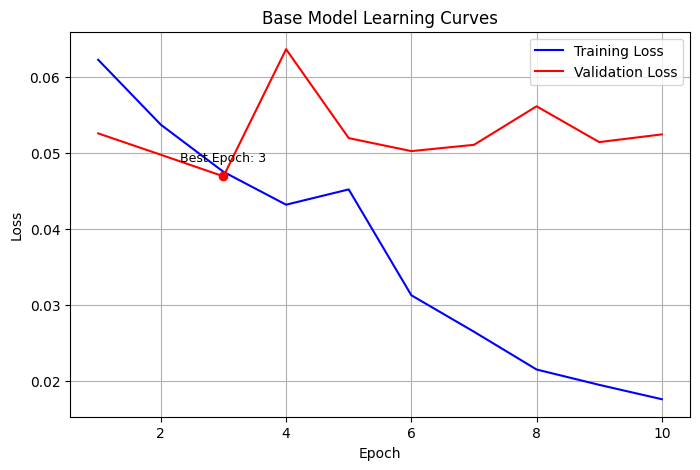

In [ ]:
# Train base model
base = vgg16_regression(mode="regressor_only", num_epochs=10, verbose=True)
base_model = base["model"]
base_results = base["metrics"]

# Print all metrics
for k, v in base_results.items():
    if isinstance(v, list):  # skip plotting curves for now
        continue
    print(f"{k.upper()}: {v:.4f}")

# Plot curves
plot_vgg16_learning_curves(base_results, title="Base Model Learning Curves")

###

# Save base model
torch.save(base_model.state_dict(), OUTPUT_DIR / "base_vgg16_model.pt")

# Save metrics
import pickle
with open(OUTPUT_DIR / "base_results.pkl", "wb") as f:
    pickle.dump(base_results, f)

### Fine tuning Experiment 1

Epoch 1/15, Train Loss: 0.0134, Val Loss: 0.0598
Epoch 2/15, Train Loss: 0.0123, Val Loss: 0.0531
Epoch 3/15, Train Loss: 0.0118, Val Loss: 0.0565
Epoch 4/15, Train Loss: 0.0111, Val Loss: 0.0569
Epoch 5/15, Train Loss: 0.0102, Val Loss: 0.0553
Epoch 6/15, Train Loss: 0.0112, Val Loss: 0.0553
Epoch 7/15, Train Loss: 0.0102, Val Loss: 0.0558
Epoch 8/15, Train Loss: 0.0118, Val Loss: 0.0577
Epoch 9/15, Train Loss: 0.0095, Val Loss: 0.0582
Epoch 10/15, Train Loss: 0.0102, Val Loss: 0.0583
Epoch 11/15, Train Loss: 0.0094, Val Loss: 0.0562
Epoch 12/15, Train Loss: 0.0097, Val Loss: 0.0579
Epoch 13/15, Train Loss: 0.0102, Val Loss: 0.0568
Epoch 14/15, Train Loss: 0.0098, Val Loss: 0.0549
Epoch 15/15, Train Loss: 0.0093, Val Loss: 0.0551
MSE: 0.0534
RMSE: 0.2311
MAE: 0.1803
R2: 0.0464


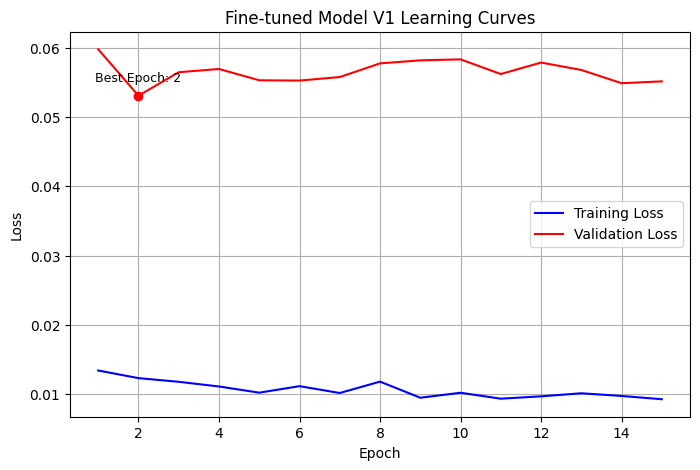

In [ ]:
# Fine tuning exp 1
ftv1 = vgg16_regression(saved_model_path=OUTPUT_DIR / "base_vgg16_model.pt", dropout=0.5, lr=0.0001, num_epochs=15, unfreeze=4, verbose=True)
ftv1_model = ftv1["model"]
ftv1_results = ftv1["metrics"]

# Print all metrics
for k, v in ftv1_results.items():
    if isinstance(v, list):  # skip plotting curves for now
        continue
    print(f"{k.upper()}: {v:.4f}")

# Plot curves
plot_vgg16_learning_curves(ftv1_results, title="Fine-tuned Model V1 Learning Curves")

###

# Save ftv1 model
torch.save(ftv1_model.state_dict(), OUTPUT_DIR / "ftv1_vgg16_model.pt")

# Save metrics
import pickle
with open(OUTPUT_DIR / "ftv1_results.pkl", "wb") as f:
    pickle.dump(ftv1_results, f)

### Experiment 2

Epoch 1/9, Train Loss: 0.0134, Val Loss: 0.0508
Epoch 2/9, Train Loss: 0.0141, Val Loss: 0.0665
Epoch 3/9, Train Loss: 0.0117, Val Loss: 0.0508
Epoch 4/9, Train Loss: 0.0094, Val Loss: 0.0542
Epoch 5/9, Train Loss: 0.0084, Val Loss: 0.0578
Epoch 6/9, Train Loss: 0.0084, Val Loss: 0.0523
Epoch 7/9, Train Loss: 0.0070, Val Loss: 0.0522
Epoch 8/9, Train Loss: 0.0072, Val Loss: 0.0631
Epoch 9/9, Train Loss: 0.0057, Val Loss: 0.0585
MSE: 0.0573
RMSE: 0.2393
MAE: 0.1923
R2: -0.0207


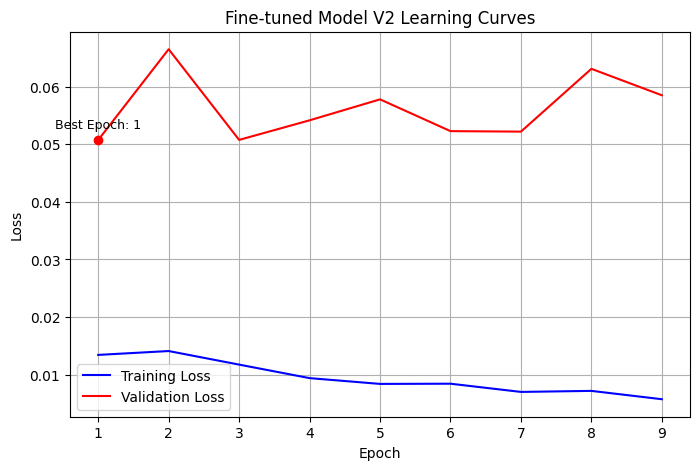

In [ ]:
# Fine tuning exp 2
ftv2 = vgg16_regression(saved_model_path=OUTPUT_DIR / "ftv1_vgg16_model.pt", dropout=0.5, lr=0.0001, num_epochs=9, unfreeze=6, verbose=True)
ftv2_model = ftv2["model"]
ftv2_results = ftv2["metrics"]

# Print all metrics
for k, v in ftv2_results.items():
    if isinstance(v, list):  # skip plotting curves for now
        continue
    print(f"{k.upper()}: {v:.4f}")

# Plot curves
plot_vgg16_learning_curves(ftv2_results, title="Fine-tuned Model V2 Learning Curves")



# Save ftv2 model
torch.save(ftv2_model.state_dict(), OUTPUT_DIR / "ftv2_vgg16_model.pt")

# Save metrics
import pickle
with open(OUTPUT_DIR / "ftv2_results.pkl", "wb") as f:
    pickle.dump(ftv2_results, f)

### Experiment 3

Epoch 1/20, Train Loss: 0.0074, Val Loss: 0.0499
Epoch 2/20, Train Loss: 0.0071, Val Loss: 0.0520
Epoch 3/20, Train Loss: 0.0085, Val Loss: 0.0504
Epoch 4/20, Train Loss: 0.0060, Val Loss: 0.0546
Epoch 5/20, Train Loss: 0.0056, Val Loss: 0.0557
Epoch 6/20, Train Loss: 0.0047, Val Loss: 0.0530
Epoch 7/20, Train Loss: 0.0043, Val Loss: 0.0535
Epoch 8/20, Train Loss: 0.0060, Val Loss: 0.0483
Epoch 9/20, Train Loss: 0.0049, Val Loss: 0.0537
Epoch 10/20, Train Loss: 0.0047, Val Loss: 0.0510
Epoch 11/20, Train Loss: 0.0046, Val Loss: 0.0529
Epoch 12/20, Train Loss: 0.0043, Val Loss: 0.0517
Epoch 13/20, Train Loss: 0.0035, Val Loss: 0.0502
Epoch 14/20, Train Loss: 0.0035, Val Loss: 0.0524
Epoch 15/20, Train Loss: 0.0033, Val Loss: 0.0556
Epoch 16/20, Train Loss: 0.0031, Val Loss: 0.0531
Epoch 17/20, Train Loss: 0.0029, Val Loss: 0.0529
Epoch 18/20, Train Loss: 0.0031, Val Loss: 0.0523
Epoch 19/20, Train Loss: 0.0027, Val Loss: 0.0555
Epoch 20/20, Train Loss: 0.0024, Val Loss: 0.0520
MSE: 0.05

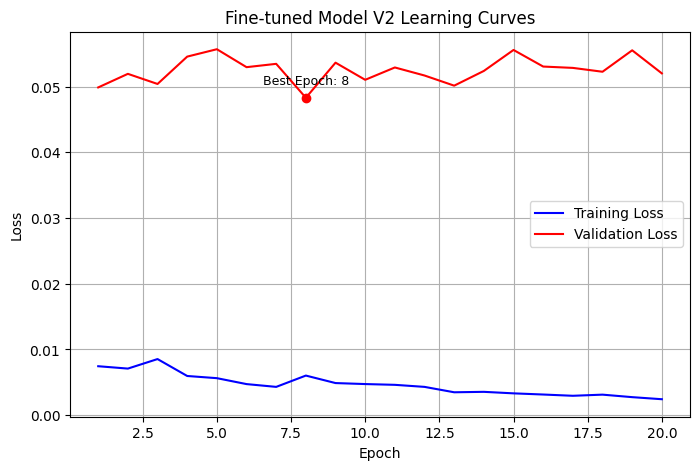

In [ ]:
# Fine tuning exp 3
ftv3 = vgg16_regression(saved_model_path=OUTPUT_DIR / "ftv2_vgg16_model.pt", dropout=0.5, lr=0.0001, num_epochs=20, unfreeze=6, verbose=True)
ftv3_model = ftv3["model"]
ftv3_results = ftv3["metrics"]

# Print all metrics
for k, v in ftv3_results.items():
    if isinstance(v, list):  # skip plotting curves for now
        continue
    print(f"{k.upper()}: {v:.4f}")

# Plot curves
plot_vgg16_learning_curves(ftv3_results, title="Fine-tuned Model V2 Learning Curves")



# Save ftv3 model
torch.save(ftv3_model.state_dict(), OUTPUT_DIR / "ftv3_vgg16_model.pt")

# Save metrics
import pickle
with open(OUTPUT_DIR / "ftv3_results.pkl", "wb") as f:
    pickle.dump(ftv3_results, f)

### Experiment 4

Epoch 1/9, Train Loss: 0.0037, Val Loss: 0.0521
Epoch 2/9, Train Loss: 0.0031, Val Loss: 0.0498
Epoch 3/9, Train Loss: 0.0032, Val Loss: 0.0529
Epoch 4/9, Train Loss: 0.0032, Val Loss: 0.0502
Epoch 5/9, Train Loss: 0.0032, Val Loss: 0.0491
Epoch 6/9, Train Loss: 0.0031, Val Loss: 0.0504
Epoch 7/9, Train Loss: 0.0039, Val Loss: 0.0527
Epoch 8/9, Train Loss: 0.0034, Val Loss: 0.0496
Epoch 9/9, Train Loss: 0.0035, Val Loss: 0.0506
MSE: 0.0495
RMSE: 0.2226
MAE: 0.1777
R2: 0.1023


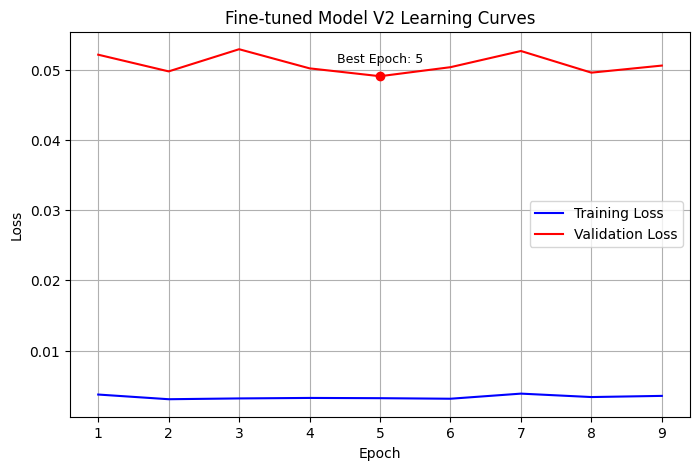

In [ ]:
# Fine tuning exp 4
ftv4 = vgg16_regression(saved_model_path=OUTPUT_DIR / "ftv3_vgg16_model.pt", dropout=0.5, lr=0.0001, num_epochs=9, unfreeze=6, verbose=True)
ftv4_model = ftv4["model"]
ftv4_results = ftv4["metrics"]

# Print all metrics
for k, v in ftv4_results.items():
    if isinstance(v, list):  # skip plotting curves for now
        continue
    print(f"{k.upper()}: {v:.4f}")

# Plot curves
plot_vgg16_learning_curves(ftv4_results, title="Fine-tuned Model V2 Learning Curves")



# Save ftv4 model
torch.save(ftv4_model.state_dict(), OUTPUT_DIR / "ftv4_vgg16_model.pt")

# Save metrics
import pickle
with open(OUTPUT_DIR / "ftv4_results.pkl", "wb") as f:
    pickle.dump(ftv4_results, f)

#Experiment 5

Epoch 1/9, Train Loss: 0.0028, Val Loss: 0.0500
Epoch 2/9, Train Loss: 0.0022, Val Loss: 0.0501
Epoch 3/9, Train Loss: 0.0024, Val Loss: 0.0498
Epoch 4/9, Train Loss: 0.0028, Val Loss: 0.0500
Epoch 5/9, Train Loss: 0.0022, Val Loss: 0.0500
Epoch 6/9, Train Loss: 0.0023, Val Loss: 0.0498
Epoch 7/9, Train Loss: 0.0023, Val Loss: 0.0498
Epoch 8/9, Train Loss: 0.0023, Val Loss: 0.0499
Epoch 9/9, Train Loss: 0.0022, Val Loss: 0.0500
MSE: 0.0490
RMSE: 0.2214
MAE: 0.1758
R2: 0.1145


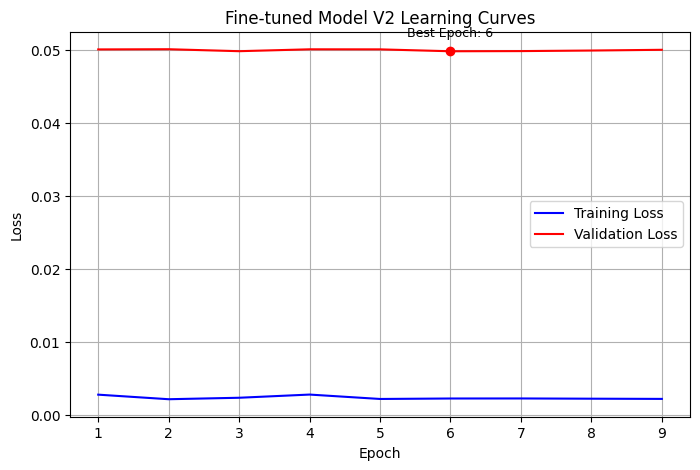

In [ ]:
# Fine tuning exp 5
ftv5 = vgg16_regression(saved_model_path=OUTPUT_DIR / "ftv4_vgg16_model.pt", dropout=0.5, lr=0.0001, num_epochs=9, unfreeze=3, verbose=True)
ftv5_model = ftv5["model"]
ftv5_results = ftv5["metrics"]

# Print all metrics
for k, v in ftv5_results.items():
    if isinstance(v, list):  # skip plotting curves for now
        continue
    print(f"{k.upper()}: {v:.4f}")

# Plot curves
plot_vgg16_learning_curves(ftv5_results, title="Fine-tuned Model V2 Learning Curves")



# Save ftv4 model
torch.save(ftv5_model.state_dict(), OUTPUT_DIR / "ftv5_vgg16_model.pt")

# Save metrics
import pickle
with open(OUTPUT_DIR / "ftv5_results.pkl", "wb") as f:
    pickle.dump(ftv4_results, f)

#Experiment 6

Epoch 1/20, Train Loss: 0.0626, Val Loss: 0.0589
Epoch 2/20, Train Loss: 0.0493, Val Loss: 0.0466
Epoch 3/20, Train Loss: 0.0371, Val Loss: 0.0529
Epoch 4/20, Train Loss: 0.0288, Val Loss: 0.0558
Epoch 5/20, Train Loss: 0.0208, Val Loss: 0.0574
Epoch 6/20, Train Loss: 0.0137, Val Loss: 0.0523
Epoch 7/20, Train Loss: 0.0111, Val Loss: 0.0535
Epoch 8/20, Train Loss: 0.0080, Val Loss: 0.0496
Epoch 9/20, Train Loss: 0.0071, Val Loss: 0.0578
Epoch 10/20, Train Loss: 0.0055, Val Loss: 0.0590
Epoch 11/20, Train Loss: 0.0054, Val Loss: 0.0535
Epoch 12/20, Train Loss: 0.0042, Val Loss: 0.0571
Epoch 13/20, Train Loss: 0.0047, Val Loss: 0.0564
Epoch 14/20, Train Loss: 0.0037, Val Loss: 0.0528
Epoch 15/20, Train Loss: 0.0031, Val Loss: 0.0592
Epoch 16/20, Train Loss: 0.0023, Val Loss: 0.0576
Epoch 17/20, Train Loss: 0.0022, Val Loss: 0.0549
Epoch 18/20, Train Loss: 0.0020, Val Loss: 0.0557
Epoch 19/20, Train Loss: 0.0026, Val Loss: 0.0530
Epoch 20/20, Train Loss: 0.0025, Val Loss: 0.0540
MSE: 0.05

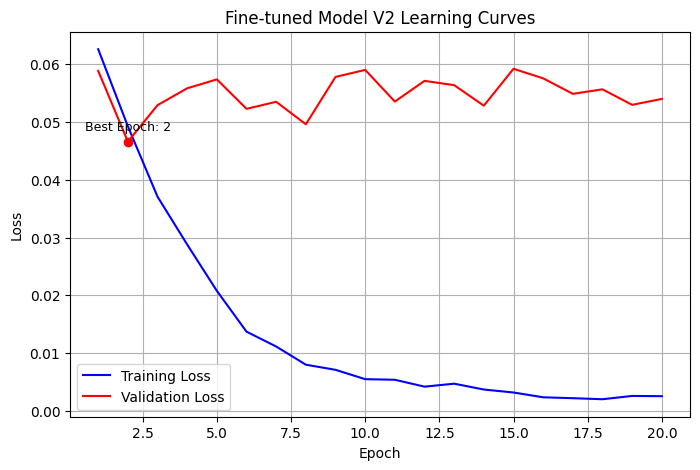

In [ ]:
# Fine tuning exp 6
ftv6 = vgg16_regression(saved_model_path=OUTPUT_DIR / "ftv5_vgg16_model.pt", dropout=0.1, lr=0.0001, num_epochs=20, unfreeze=6, verbose=True)
ftv6_model = ftv6["model"]
ftv6_results = ftv6["metrics"]

# Print all metrics
for k, v in ftv6_results.items():
    if isinstance(v, list):  # skip plotting curves for now
        continue
    print(f"{k.upper()}: {v:.4f}")

# Plot curves
plot_vgg16_learning_curves(ftv6_results, title="Fine-tuned Model V2 Learning Curves")



# Save ftv3 model
torch.save(ftv6_model.state_dict(), OUTPUT_DIR / "ftv6_vgg16_model.pt")

# Save metrics
import pickle
with open(OUTPUT_DIR / "ftv6_results.pkl", "wb") as f:
    pickle.dump(ftv6_results, f)

#Experiment 7

Epoch 1/20, Train Loss: 0.0701, Val Loss: 0.0582
Epoch 2/20, Train Loss: 0.0532, Val Loss: 0.0544
Epoch 3/20, Train Loss: 0.0491, Val Loss: 0.0505
Epoch 4/20, Train Loss: 0.0451, Val Loss: 0.0489
Epoch 5/20, Train Loss: 0.0404, Val Loss: 0.0479
Epoch 6/20, Train Loss: 0.0350, Val Loss: 0.0537
Epoch 7/20, Train Loss: 0.0318, Val Loss: 0.0475
Epoch 8/20, Train Loss: 0.0267, Val Loss: 0.0491
Epoch 9/20, Train Loss: 0.0221, Val Loss: 0.0503
Epoch 10/20, Train Loss: 0.0192, Val Loss: 0.0505
Epoch 11/20, Train Loss: 0.0160, Val Loss: 0.0497
Epoch 12/20, Train Loss: 0.0132, Val Loss: 0.0512
Epoch 13/20, Train Loss: 0.0106, Val Loss: 0.0513
Epoch 14/20, Train Loss: 0.0089, Val Loss: 0.0514
Epoch 15/20, Train Loss: 0.0076, Val Loss: 0.0493
Epoch 16/20, Train Loss: 0.0065, Val Loss: 0.0538
Epoch 17/20, Train Loss: 0.0055, Val Loss: 0.0502
Epoch 18/20, Train Loss: 0.0048, Val Loss: 0.0529
Epoch 19/20, Train Loss: 0.0042, Val Loss: 0.0515
Epoch 20/20, Train Loss: 0.0033, Val Loss: 0.0526
MSE: 0.05

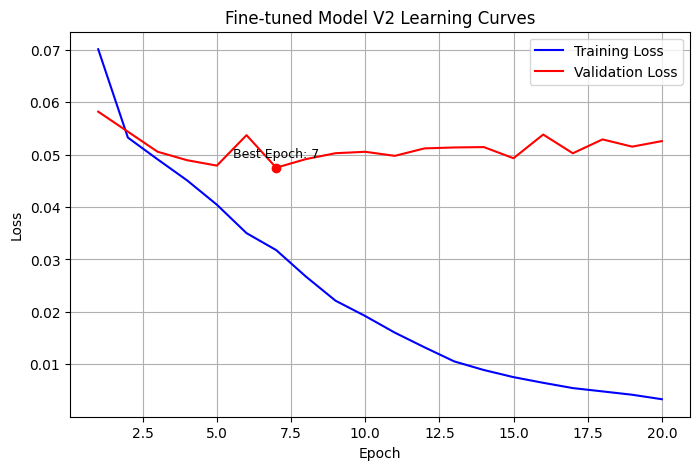

In [ ]:
# Fine tuning exp 7
ftv7 = vgg16_regression(saved_model_path=OUTPUT_DIR / "ftv6_vgg16_model.pt", dropout=0.1, lr=0.00001, num_epochs=20, unfreeze=6, verbose=True)
ftv7_model = ftv7["model"]
ftv7_results = ftv7["metrics"]

# Print all metrics
for k, v in ftv7_results.items():
    if isinstance(v, list):  # skip plotting curves for now
        continue
    print(f"{k.upper()}: {v:.4f}")

# Plot curves
plot_vgg16_learning_curves(ftv7_results, title="Fine-tuned Model V2 Learning Curves")



# Save ftv3 model
torch.save(ftv7_model.state_dict(), OUTPUT_DIR / "ftv7_vgg16_model.pt")

# Save metrics
import pickle
with open(OUTPUT_DIR / "ftv7_results.pkl", "wb") as f:
    pickle.dump(ftv7_results, f)

#Experiment 8

Epoch 1/20, Train Loss: 0.0666, Val Loss: 0.0617
Epoch 2/20, Train Loss: 0.0553, Val Loss: 0.0552
Epoch 3/20, Train Loss: 0.0514, Val Loss: 0.0534
Epoch 4/20, Train Loss: 0.0474, Val Loss: 0.0509
Epoch 5/20, Train Loss: 0.0418, Val Loss: 0.0515
Epoch 6/20, Train Loss: 0.0401, Val Loss: 0.0458
Epoch 7/20, Train Loss: 0.0350, Val Loss: 0.0468
Epoch 8/20, Train Loss: 0.0302, Val Loss: 0.0511
Epoch 9/20, Train Loss: 0.0264, Val Loss: 0.0469
Epoch 10/20, Train Loss: 0.0228, Val Loss: 0.0480
Epoch 11/20, Train Loss: 0.0196, Val Loss: 0.0481
Epoch 12/20, Train Loss: 0.0164, Val Loss: 0.0484
Epoch 13/20, Train Loss: 0.0137, Val Loss: 0.0501
Epoch 14/20, Train Loss: 0.0116, Val Loss: 0.0501
Epoch 15/20, Train Loss: 0.0099, Val Loss: 0.0521
Epoch 16/20, Train Loss: 0.0083, Val Loss: 0.0527
Epoch 17/20, Train Loss: 0.0074, Val Loss: 0.0550
Epoch 18/20, Train Loss: 0.0069, Val Loss: 0.0526
Epoch 19/20, Train Loss: 0.0059, Val Loss: 0.0528
Epoch 20/20, Train Loss: 0.0052, Val Loss: 0.0532
MSE: 0.05

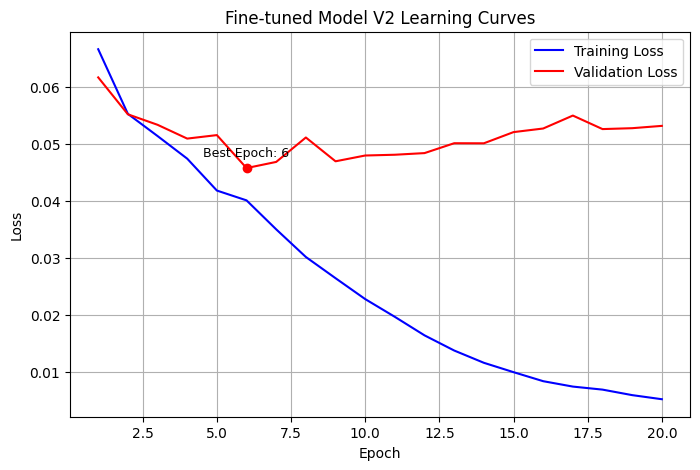

In [ ]:
# Fine tuning exp 8
ftv8 = vgg16_regression(saved_model_path=OUTPUT_DIR / "ftv7_vgg16_model.pt", dropout=0.2, lr=0.00001, num_epochs=20, unfreeze=6, verbose=True)
ftv8_model = ftv8["model"]
ftv8_results = ftv8["metrics"]

# Print all metrics
for k, v in ftv8_results.items():
    if isinstance(v, list):  # skip plotting curves for now
        continue
    print(f"{k.upper()}: {v:.4f}")

# Plot curves
plot_vgg16_learning_curves(ftv8_results, title="Fine-tuned Model V2 Learning Curves")



# Save ftv3 model
torch.save(ftv8_model.state_dict(), OUTPUT_DIR / "ftv8_vgg16_model.pt")

# Save metrics
import pickle
with open(OUTPUT_DIR / "ftv8_results.pkl", "wb") as f:
    pickle.dump(ftv8_results, f)

#Experiment 9

Epoch 1/20, Train Loss: 0.0758, Val Loss: 0.0585
Epoch 2/20, Train Loss: 0.0557, Val Loss: 0.0573
Epoch 3/20, Train Loss: 0.0557, Val Loss: 0.0552
Epoch 4/20, Train Loss: 0.0546, Val Loss: 0.0542
Epoch 5/20, Train Loss: 0.0524, Val Loss: 0.0521
Epoch 6/20, Train Loss: 0.0501, Val Loss: 0.0511
Epoch 7/20, Train Loss: 0.0495, Val Loss: 0.0499
Epoch 8/20, Train Loss: 0.0483, Val Loss: 0.0486
Epoch 9/20, Train Loss: 0.0452, Val Loss: 0.0483
Epoch 10/20, Train Loss: 0.0430, Val Loss: 0.0466
Epoch 11/20, Train Loss: 0.0417, Val Loss: 0.0464
Epoch 12/20, Train Loss: 0.0394, Val Loss: 0.0466
Epoch 13/20, Train Loss: 0.0406, Val Loss: 0.0462
Epoch 14/20, Train Loss: 0.0364, Val Loss: 0.0466
Epoch 15/20, Train Loss: 0.0365, Val Loss: 0.0457
Epoch 16/20, Train Loss: 0.0339, Val Loss: 0.0469
Epoch 17/20, Train Loss: 0.0323, Val Loss: 0.0474
Epoch 18/20, Train Loss: 0.0304, Val Loss: 0.0471
Epoch 19/20, Train Loss: 0.0302, Val Loss: 0.0478
Epoch 20/20, Train Loss: 0.0272, Val Loss: 0.0476
MSE: 0.04

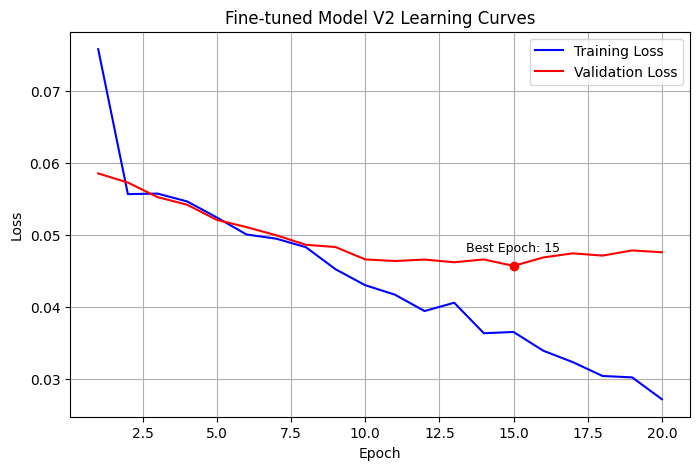

In [ ]:
# Fine tuning exp 9
ftv9 = vgg16_regression(saved_model_path=OUTPUT_DIR / "ftv8_vgg16_model.pt", dropout=0.6, lr=0.00001, num_epochs=20, unfreeze=6, verbose=True)
ftv9_model = ftv9["model"]
ftv9_results = ftv9["metrics"]

# Print all metrics
for k, v in ftv9_results.items():
    if isinstance(v, list):  # skip plotting curves for now
        continue
    print(f"{k.upper()}: {v:.4f}")

# Plot curves
plot_vgg16_learning_curves(ftv9_results, title="Fine-tuned Model V2 Learning Curves")



# Save ftv3 model
torch.save(ftv9_model.state_dict(), OUTPUT_DIR / "ftv9_vgg16_model.pt")

# Save metrics
import pickle
with open(OUTPUT_DIR / "ftv9_results.pkl", "wb") as f:
    pickle.dump(ftv9_results, f)

#Experiment 10

Epoch 1/20, Train Loss: 0.0841, Val Loss: 0.0580
Epoch 2/20, Train Loss: 0.0570, Val Loss: 0.0587
Epoch 3/20, Train Loss: 0.0567, Val Loss: 0.0555
Epoch 4/20, Train Loss: 0.0552, Val Loss: 0.0547
Epoch 5/20, Train Loss: 0.0515, Val Loss: 0.0556
Epoch 6/20, Train Loss: 0.0518, Val Loss: 0.0511
Epoch 7/20, Train Loss: 0.0505, Val Loss: 0.0520
Epoch 8/20, Train Loss: 0.0474, Val Loss: 0.0490
Epoch 9/20, Train Loss: 0.0467, Val Loss: 0.0481
Epoch 10/20, Train Loss: 0.0466, Val Loss: 0.0465
Epoch 11/20, Train Loss: 0.0439, Val Loss: 0.0463
Epoch 12/20, Train Loss: 0.0428, Val Loss: 0.0454
Epoch 13/20, Train Loss: 0.0413, Val Loss: 0.0454
Epoch 14/20, Train Loss: 0.0386, Val Loss: 0.0456
Epoch 15/20, Train Loss: 0.0367, Val Loss: 0.0452
Epoch 16/20, Train Loss: 0.0359, Val Loss: 0.0456
Epoch 17/20, Train Loss: 0.0345, Val Loss: 0.0453
Epoch 18/20, Train Loss: 0.0311, Val Loss: 0.0473
Epoch 19/20, Train Loss: 0.0323, Val Loss: 0.0465
Epoch 20/20, Train Loss: 0.0287, Val Loss: 0.0464
MSE: 0.04

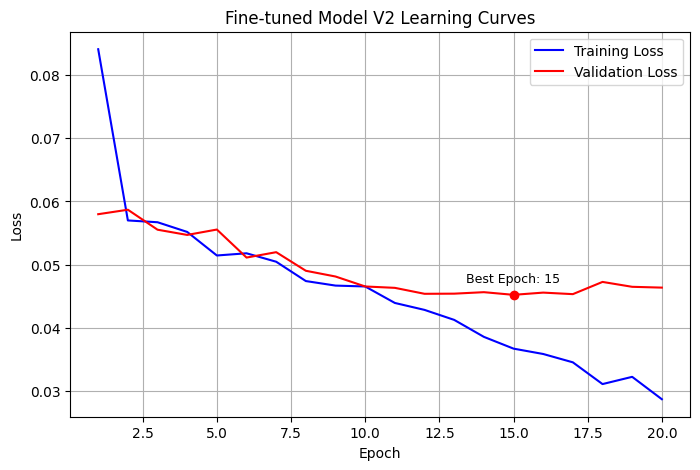

In [ ]:
# Fine tuning exp 10
ftv10 = vgg16_regression(saved_model_path=OUTPUT_DIR / "ftv9_vgg16_model.pt", dropout=0.6, lr=0.00001, num_epochs=20, unfreeze=4, verbose=True)
ftv10_model = ftv10["model"]
ftv10_results = ftv10["metrics"]

# Print all metrics
for k, v in ftv10_results.items():
    if isinstance(v, list):  # skip plotting curves for now
        continue
    print(f"{k.upper()}: {v:.4f}")

# Plot curves
plot_vgg16_learning_curves(ftv10_results, title="Fine-tuned Model V2 Learning Curves")



# Save ftv3 model
torch.save(ftv10_model.state_dict(), OUTPUT_DIR / "ftv10_vgg16_model.pt")

# Save metrics
import pickle
with open(OUTPUT_DIR / "ftv10_results.pkl", "wb") as f:
    pickle.dump(ftv10_results, f)

#Experiment 11

Epoch 1/20, Train Loss: 0.0867, Val Loss: 0.0579
Epoch 2/20, Train Loss: 0.0608, Val Loss: 0.0582
Epoch 3/20, Train Loss: 0.0577, Val Loss: 0.0566
Epoch 4/20, Train Loss: 0.0574, Val Loss: 0.0557
Epoch 5/20, Train Loss: 0.0565, Val Loss: 0.0548
Epoch 6/20, Train Loss: 0.0543, Val Loss: 0.0541
Epoch 7/20, Train Loss: 0.0546, Val Loss: 0.0537
Epoch 8/20, Train Loss: 0.0532, Val Loss: 0.0523
Epoch 9/20, Train Loss: 0.0521, Val Loss: 0.0508
Epoch 10/20, Train Loss: 0.0521, Val Loss: 0.0524
Epoch 11/20, Train Loss: 0.0499, Val Loss: 0.0491
Epoch 12/20, Train Loss: 0.0493, Val Loss: 0.0486
Epoch 13/20, Train Loss: 0.0477, Val Loss: 0.0487
Epoch 14/20, Train Loss: 0.0443, Val Loss: 0.0473
Epoch 15/20, Train Loss: 0.0423, Val Loss: 0.0472
Epoch 16/20, Train Loss: 0.0436, Val Loss: 0.0467
Epoch 17/20, Train Loss: 0.0426, Val Loss: 0.0463
Epoch 18/20, Train Loss: 0.0413, Val Loss: 0.0461
Epoch 19/20, Train Loss: 0.0407, Val Loss: 0.0452
Epoch 20/20, Train Loss: 0.0386, Val Loss: 0.0454
MSE: 0.04

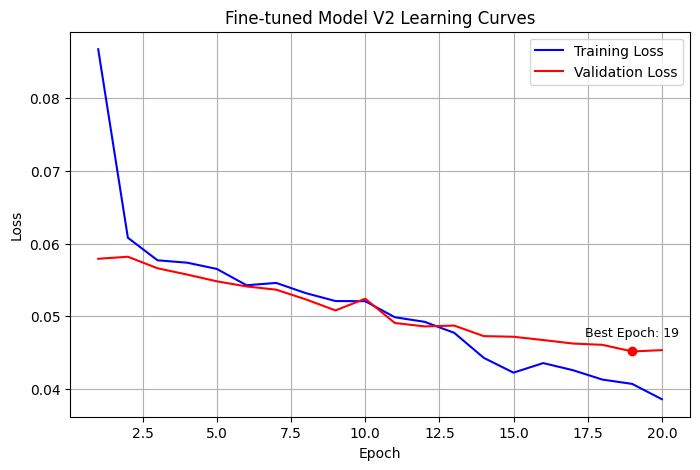

In [ ]:
# Fine tuning exp 11
ftv11 = vgg16_regression(saved_model_path=OUTPUT_DIR / "ftv10_vgg16_model.pt", dropout=0.7, lr=0.00001, num_epochs=20, unfreeze=6, verbose=True)
ftv11_model = ftv11["model"]
ftv11_results = ftv11["metrics"]

# Print all metrics
for k, v in ftv11_results.items():
    if isinstance(v, list):  # skip plotting curves for now
        continue
    print(f"{k.upper()}: {v:.4f}")

# Plot curves
plot_vgg16_learning_curves(ftv11_results, title="Fine-tuned Model V2 Learning Curves")



# Save ftv3 model
torch.save(ftv11_model.state_dict(), OUTPUT_DIR / "ftv11_vgg16_model.pt")

# Save metrics
import pickle
with open(OUTPUT_DIR / "ftv11_results.pkl", "wb") as f:
    pickle.dump(ftv11_results, f)

#Experiment 12

Epoch 1/20, Train Loss: 0.0729, Val Loss: 0.0691
Epoch 2/20, Train Loss: 0.0679, Val Loss: 0.0586
Epoch 3/20, Train Loss: 0.0660, Val Loss: 0.0511
Epoch 4/20, Train Loss: 0.0596, Val Loss: 0.0578
Epoch 5/20, Train Loss: 0.0571, Val Loss: 0.0480
Epoch 6/20, Train Loss: 0.0556, Val Loss: 0.0480
Epoch 7/20, Train Loss: 0.0510, Val Loss: 0.0480
Epoch 8/20, Train Loss: 0.0473, Val Loss: 0.0463
Epoch 9/20, Train Loss: 0.0442, Val Loss: 0.0461
Epoch 10/20, Train Loss: 0.0430, Val Loss: 0.0505
Epoch 11/20, Train Loss: 0.0425, Val Loss: 0.0486
Epoch 12/20, Train Loss: 0.0391, Val Loss: 0.0502
Epoch 13/20, Train Loss: 0.0356, Val Loss: 0.0541
Epoch 14/20, Train Loss: 0.0341, Val Loss: 0.0509
Epoch 15/20, Train Loss: 0.0304, Val Loss: 0.0504
Epoch 16/20, Train Loss: 0.0305, Val Loss: 0.0611
Epoch 17/20, Train Loss: 0.0280, Val Loss: 0.0568
Epoch 18/20, Train Loss: 0.0246, Val Loss: 0.0547
Epoch 19/20, Train Loss: 0.0230, Val Loss: 0.0526
Epoch 20/20, Train Loss: 0.0232, Val Loss: 0.0515
MSE: 0.05

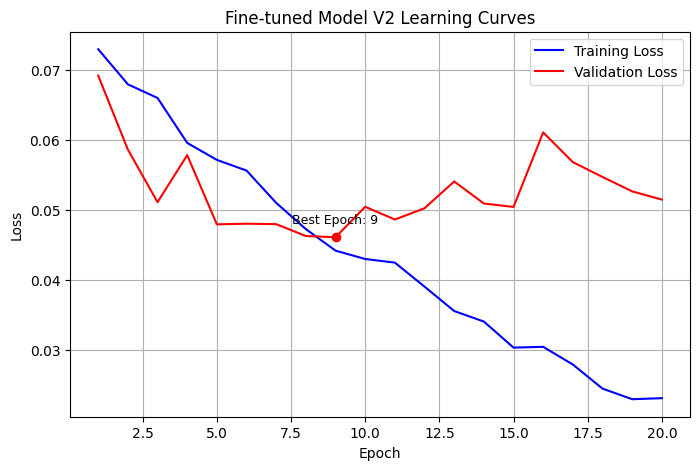

In [ ]:
# Fine tuning exp 12
ftv12 = vgg16_regression(saved_model_path=OUTPUT_DIR / "ftv11_vgg16_model.pt", dropout=0.7, lr=0.0001, num_epochs=20, unfreeze=6, verbose=True)
ftv12_model = ftv12["model"]
ftv12_results = ftv12["metrics"]

# Print all metrics
for k, v in ftv12_results.items():
    if isinstance(v, list):  # skip plotting curves for now
        continue
    print(f"{k.upper()}: {v:.4f}")

# Plot curves
plot_vgg16_learning_curves(ftv12_results, title="Fine-tuned Model V2 Learning Curves")



# Save ftv3 model
torch.save(ftv12_model.state_dict(), OUTPUT_DIR / "ftv12_vgg16_model.pt")

# Save metrics
import pickle
with open(OUTPUT_DIR / "ftv12_results.pkl", "wb") as f:
    pickle.dump(ftv12_results, f)

#Experiment 13

Epoch 1/25, Train Loss: 0.0865, Val Loss: 0.0575
Epoch 2/25, Train Loss: 0.0574, Val Loss: 0.0585
Epoch 3/25, Train Loss: 0.0582, Val Loss: 0.0567
Epoch 4/25, Train Loss: 0.0569, Val Loss: 0.0557
Epoch 5/25, Train Loss: 0.0563, Val Loss: 0.0557
Epoch 6/25, Train Loss: 0.0547, Val Loss: 0.0542
Epoch 7/25, Train Loss: 0.0550, Val Loss: 0.0530
Epoch 8/25, Train Loss: 0.0534, Val Loss: 0.0521
Epoch 9/25, Train Loss: 0.0507, Val Loss: 0.0520
Epoch 10/25, Train Loss: 0.0518, Val Loss: 0.0503
Epoch 11/25, Train Loss: 0.0503, Val Loss: 0.0510
Epoch 12/25, Train Loss: 0.0469, Val Loss: 0.0484
Epoch 13/25, Train Loss: 0.0483, Val Loss: 0.0480
Epoch 14/25, Train Loss: 0.0465, Val Loss: 0.0478
Epoch 15/25, Train Loss: 0.0433, Val Loss: 0.0473
Epoch 16/25, Train Loss: 0.0429, Val Loss: 0.0462
Epoch 17/25, Train Loss: 0.0443, Val Loss: 0.0472
Epoch 18/25, Train Loss: 0.0418, Val Loss: 0.0465
Epoch 19/25, Train Loss: 0.0404, Val Loss: 0.0470
Epoch 20/25, Train Loss: 0.0403, Val Loss: 0.0455
Epoch 21/

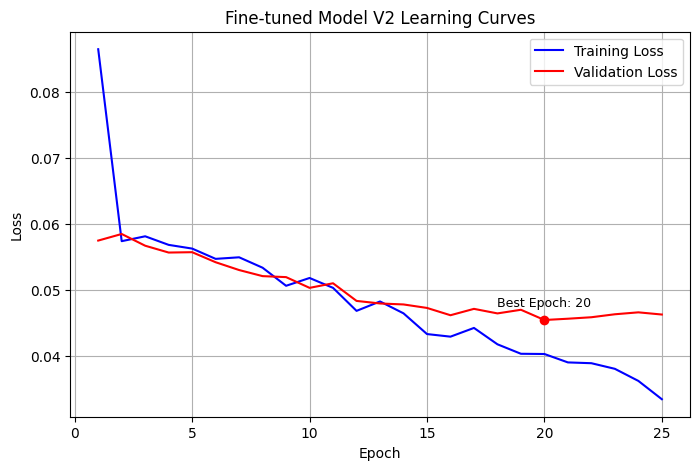

In [ ]:
# Fine tuning exp 13
ftv13 = vgg16_regression(saved_model_path=OUTPUT_DIR / "ftv12_vgg16_model.pt", dropout=0.7, lr=0.00001, num_epochs=25, unfreeze=6, verbose=True)
ftv13_model = ftv13["model"]
ftv13_results = ftv13["metrics"]

# Print all metrics
for k, v in ftv13_results.items():
    if isinstance(v, list):  # skip plotting curves for now
        continue
    print(f"{k.upper()}: {v:.4f}")

# Plot curves
plot_vgg16_learning_curves(ftv13_results, title="Fine-tuned Model V2 Learning Curves")



# Save ftv3 model
torch.save(ftv13_model.state_dict(), OUTPUT_DIR / "ftv13_vgg16_model.pt")

# Save metrics
import pickle
with open(OUTPUT_DIR / "ftv13_results.pkl", "wb") as f:
    pickle.dump(ftv13_results, f)